In [1]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


In [2]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list

def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:640,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB

In [3]:
measured, smoothed = load_directory(r'meas_data_13_Mar_2026(sample2)', window=11, poly=3)

In [4]:
measured

[2-Port Network: 'calibration_data',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set01_3g',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set01_4g',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set01_5g',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set_04_25_5',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set_07_14_5',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set_07_17_5',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set_07_20_5',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set_07_23_5',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'sample_01_set_07_25_5',  1000000000.0-4498

In [5]:
calibration_data, smoothed_calibration_data = measured[0], smoothed[0]  # First 
sample_01_set07, smoothed_sample_01_set07 = measured[5:10], smoothed[5:10]  # 
sample_02_set07, smoothed_sample_02_set07 = measured[14:19], smoothed[14:19]  #
sample_02_set01_Gwidths, smoothed_sample_02_set01_Gwidths = measured[10:14], smoothed[10:14]  #
sample_01_set01_Gwidths, smoothed_sample_01_set01_Gwidths = measured[1:4], smoothed[1:4]  #


In [6]:
smoothed_calibration_data

2-Port Network: 'calibration_data',  1000000000.0-44980000000.0 Hz, 1467 pts, z0=[50.+0.j 50.+0.j]

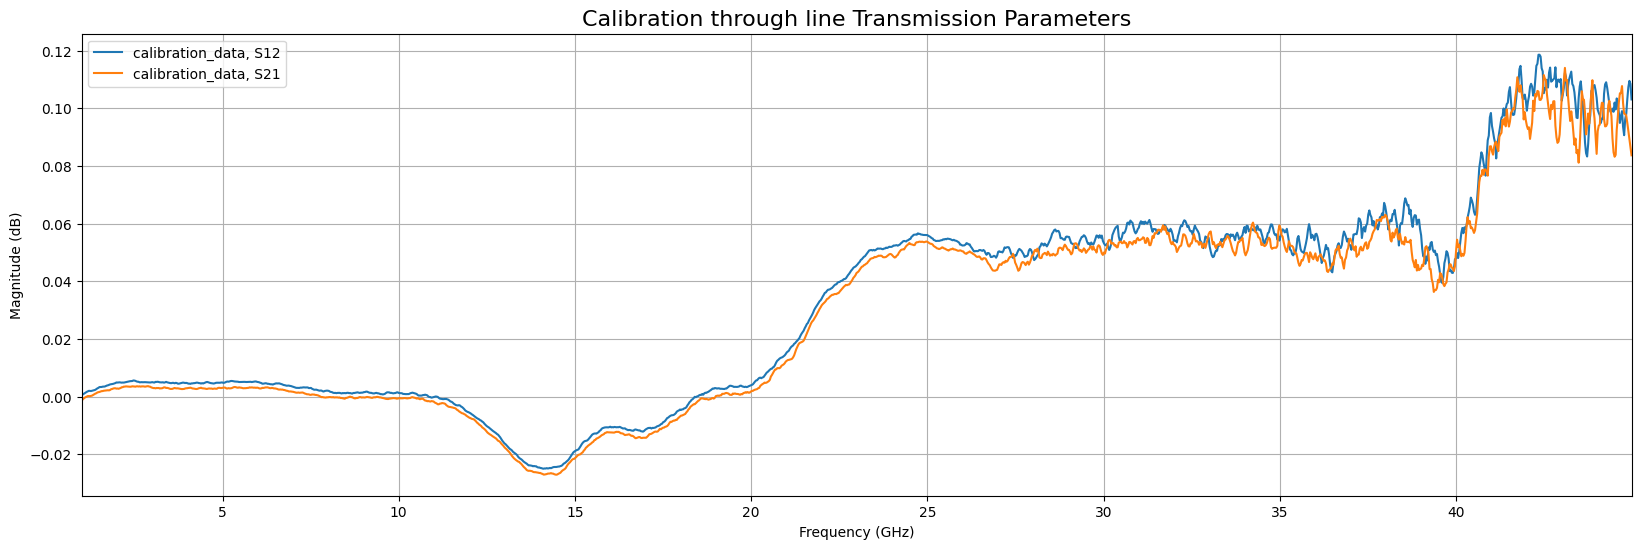

In [7]:
plt.figure(figsize=(20, 6))
plt.title('Calibration through line Transmission Parameters', fontsize=16)
smoothed_calibration_data.frequency.unit = 'GHz'
smoothed_calibration_data.plot_s_db(m=0,n=1)
smoothed_calibration_data.plot_s_db(m=1,n=0)

plt.grid()
plt.savefig('Plotted_results_13_march/Calibration through line Transmission Parameters', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

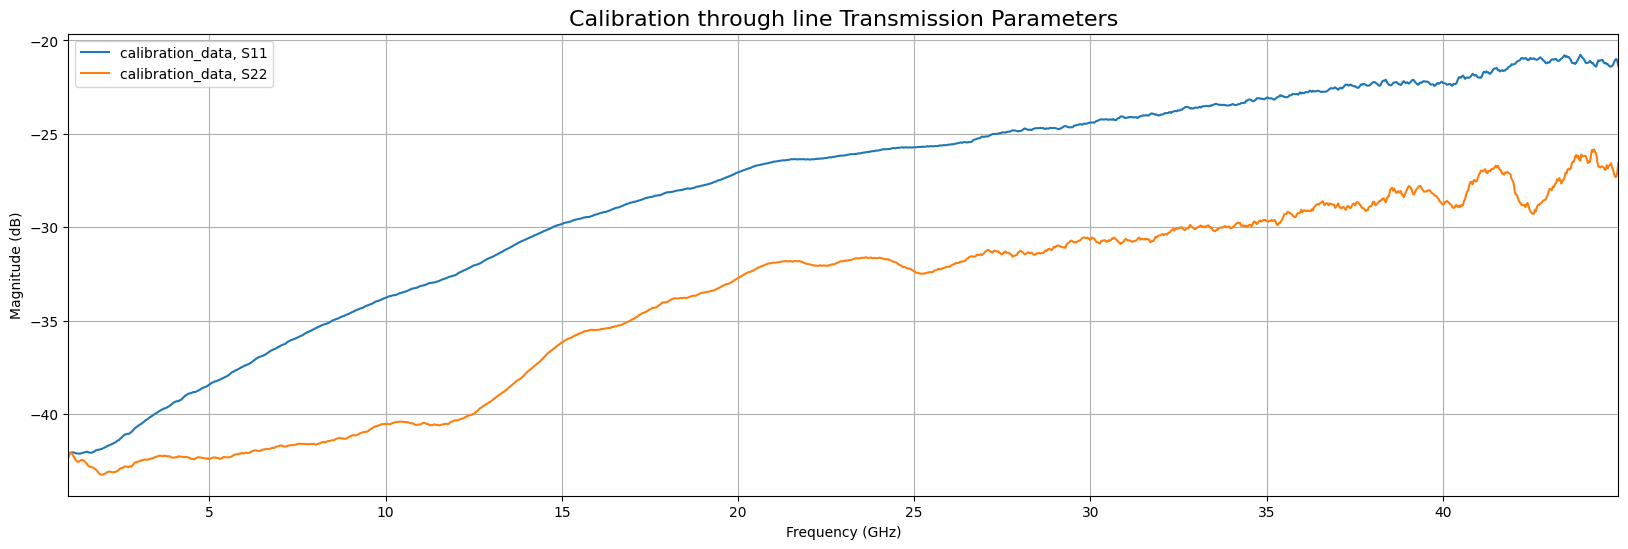

In [8]:
plt.figure(figsize=(20, 6))
plt.title('Calibration through line Transmission Parameters', fontsize=16)
smoothed_calibration_data.frequency.unit = 'GHz'
smoothed_calibration_data.plot_s_db(m=0,n=0)
smoothed_calibration_data.plot_s_db(m=1,n=1)

plt.grid()
plt.savefig('Plotted_results_13_march/Calibration through line Transmission Parameters', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

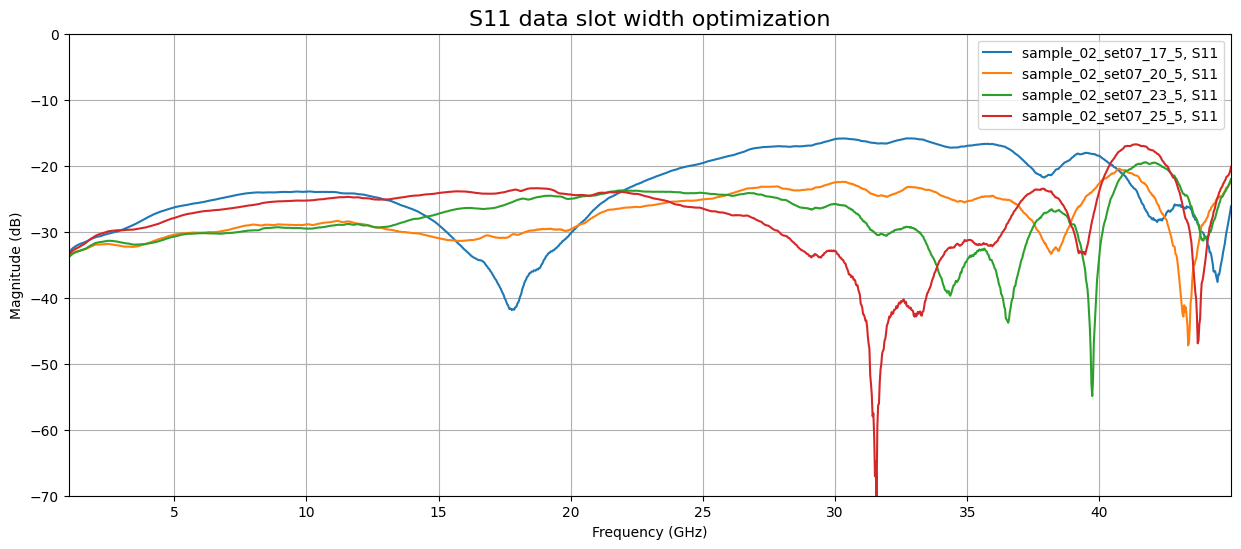

In [18]:
plt.figure(figsize=(15, 6))
plt.title('S11 data slot width optimization', fontsize=16)
for ntwk in smoothed_sample_02_set07[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)
plt.grid()
plt.ylim(-70, 0)  # Set y-axis limits for better visualization
plt.savefig('Plotted_results_13_march/S11 data slot width optimization', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

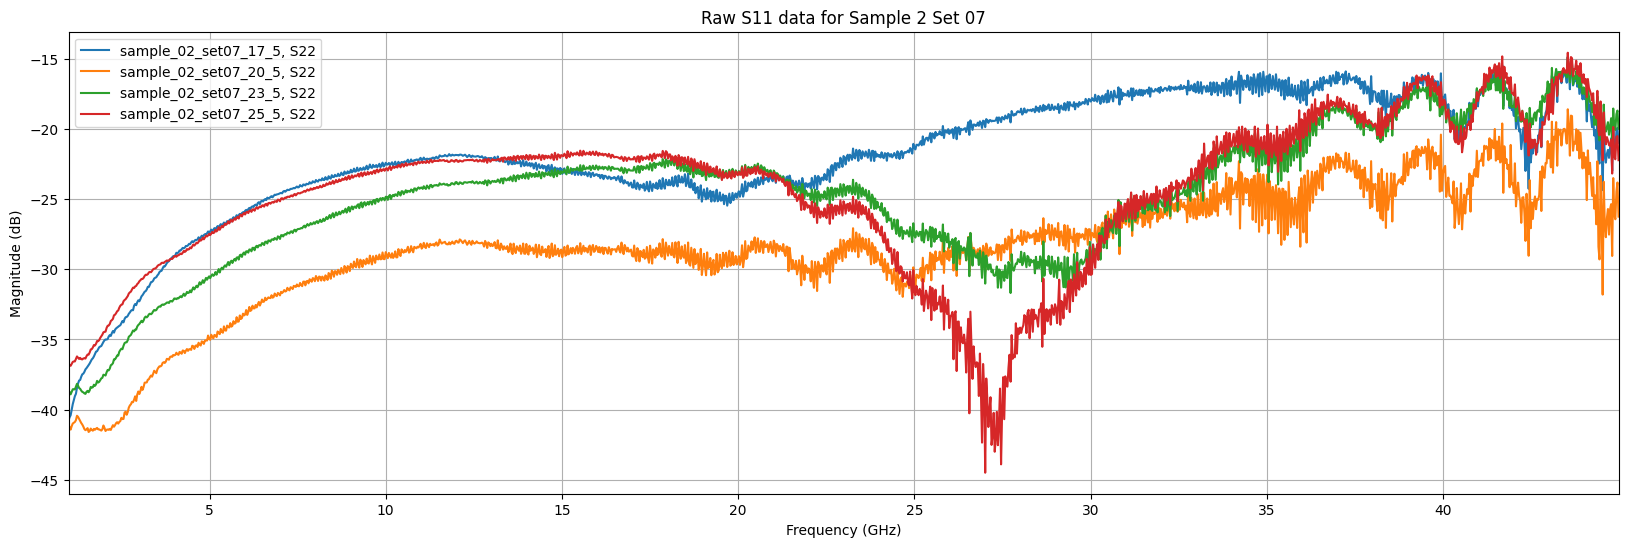

In [10]:
plt.figure(figsize=(20, 6))
plt.title('Raw S11 data for Sample 2 Set 07')
for ntwk in sample_02_set07[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=1)   
plt.grid()


plt.savefig('Plotted_results_13_march/Raw S11 data for Sample 2 Set 07', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

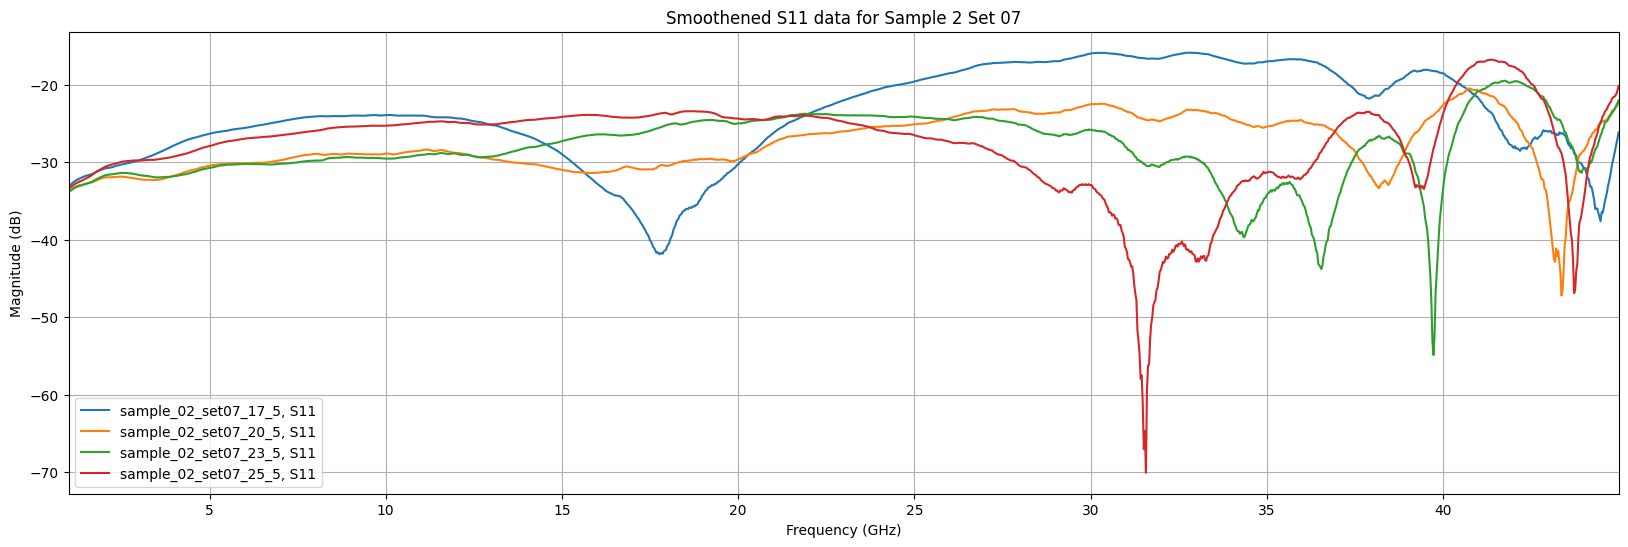

In [16]:
plt.figure(figsize=(20, 6))
plt.title('Smoothened S11 data for Sample 2 Set 07')
for ntwk in smoothed_sample_02_set07[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)
plt.grid()


plt.savefig('Plotted_results_13_march/Smoothened S11 data for Sample 2 Set 07', dpi=300, bbox_inches='tight') # Save the figure with high resolution and tight layout

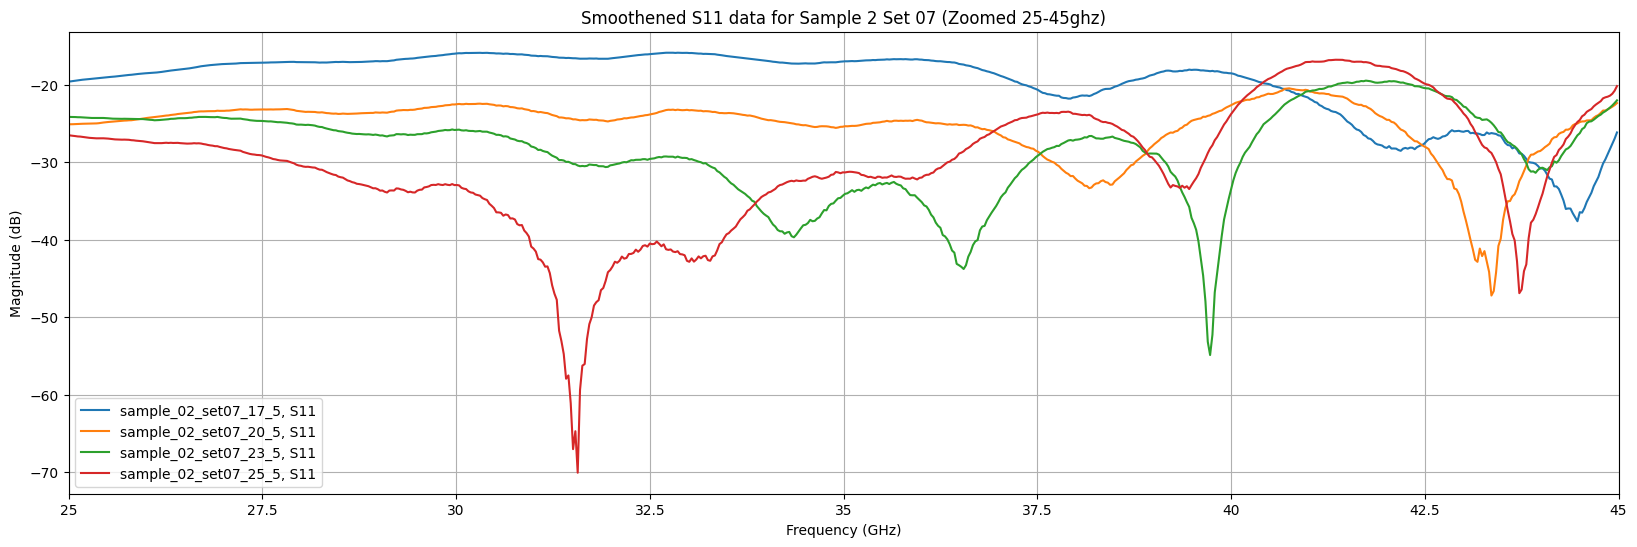

In [10]:
plt.figure(figsize=(20, 6))
plt.title('Smoothened S11 data for Sample 2 Set 07 (Zoomed 25-45ghz)')
for ntwk in smoothed_sample_02_set07[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)
plt.xlim(25e9,45e9)
plt.grid()

plt.savefig('Plotted_results_13_march/Smoothened S11 data (25to45ghz)', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

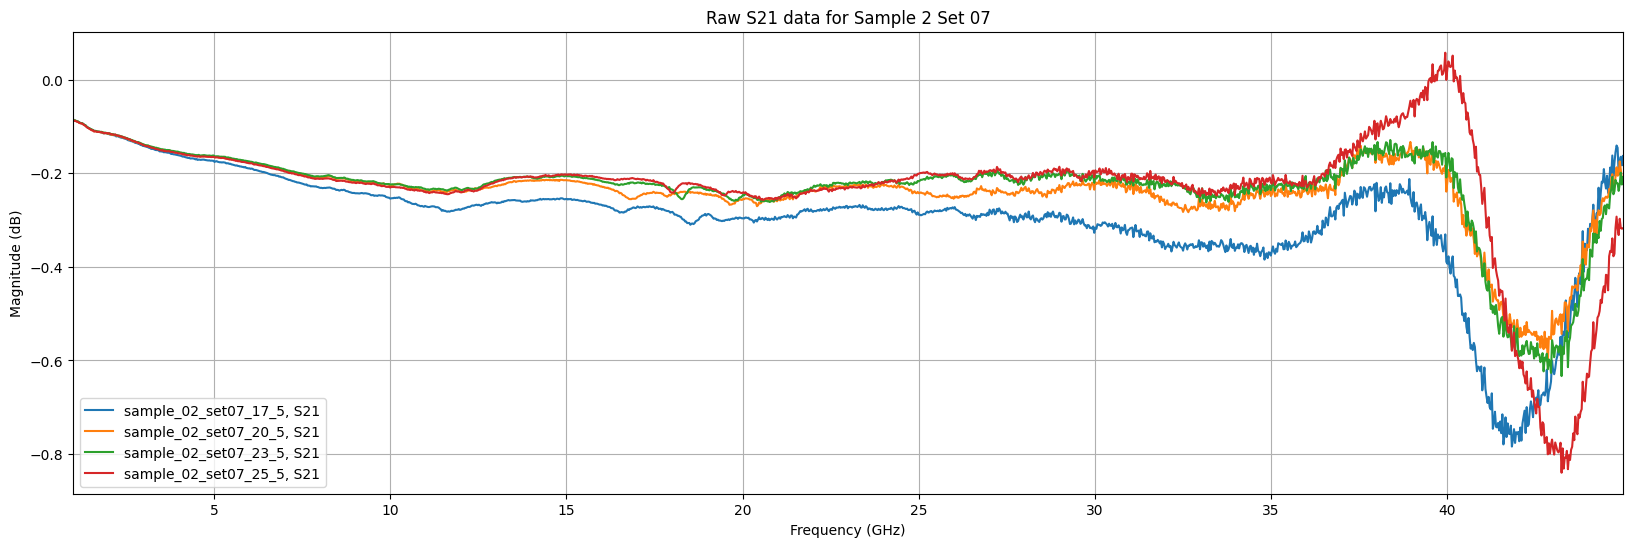

In [81]:
plt.figure(figsize=(20, 6))
plt.title('Raw S21 data for Sample 2 Set 07')
for ntwk in sample_02_set07[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0)   
plt.grid()


plt.savefig('Plotted_results_13_march/Raw S21 data for Sample 2 Set 07', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

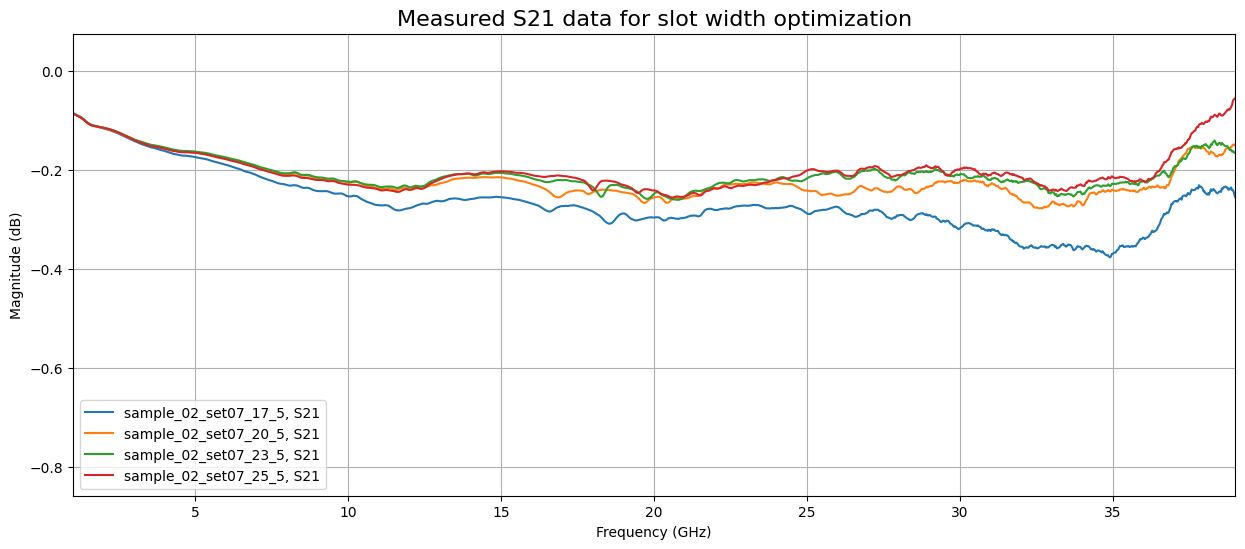

In [22]:
plt.figure(figsize=(15, 6))
plt.title('Measured S21 data for slot width optimization', fontsize=16)
for ntwk in smoothed_sample_02_set07[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0)   
plt.grid()
plt.xlim(1e9,39e9)


plt.savefig('Plotted_results_13_march/smoothened S21 data for Sample 2 Set 07', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

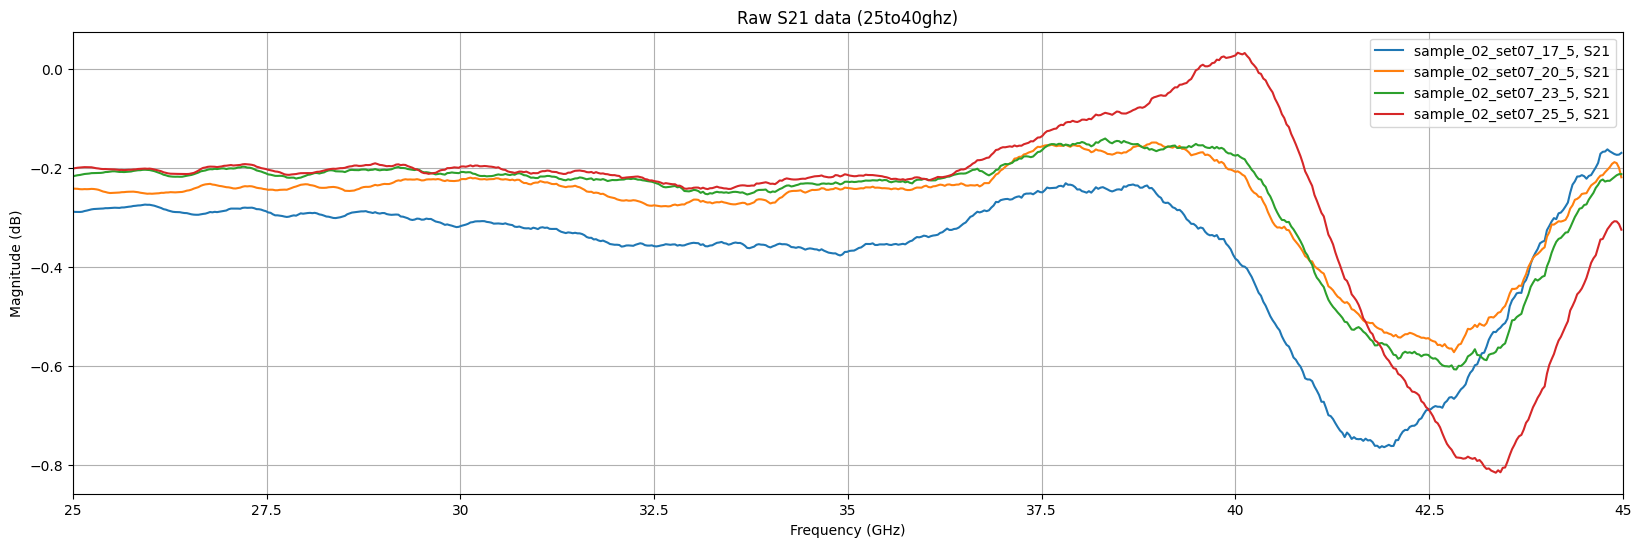

In [84]:
plt.figure(figsize=(20, 6))
plt.title('Raw S21 data (25to40ghz)')
for ntwk in smoothed_sample_02_set07[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0)  
plt.xlim(25e9,45e9) 
plt.grid()


plt.savefig('Plotted_results_13_march/smoothened S21 data (25to40ghz)', dpi=300, bbox_inches='tight') 
# Save the figure with high resolution and tight layout

(25000000000.0, 45000000000.0)

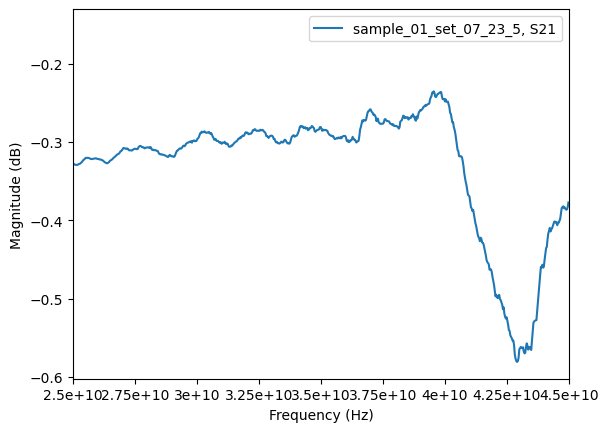

In [87]:
smoothed_sample_01_set07[3].plot_s_db(m=1,n=0)
plt.xlim(25e9,45e9)